In [83]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

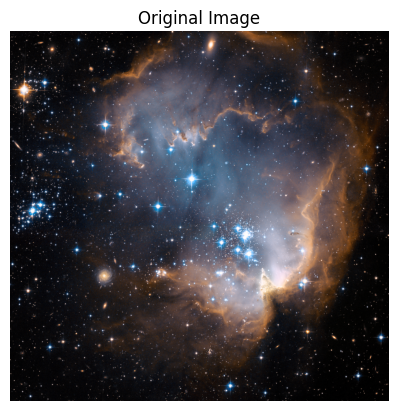

In [84]:
# Step 1 #
img = 'Session_3/009_new_stars_past_light.jpg'
img_clr = cv2.imread(img, cv2.IMREAD_COLOR_RGB)
plt.imshow(img_clr)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [85]:
print(img_clr.shape)
b = img_clr[:,:,0]
g = img_clr[:,:,1]
r = img_clr[:,:,2]

(3659, 3749, 3)


B_Mean: 54.21495100706822 G_Mean: 50.236461853980046 R_Mean: 54.4032431058777
B_StdDev: 54.24588945244075 G_StdDev: 49.119842176085946 R_StdDev: 54.578263116799214


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0227325583394835..4.168652199898747].


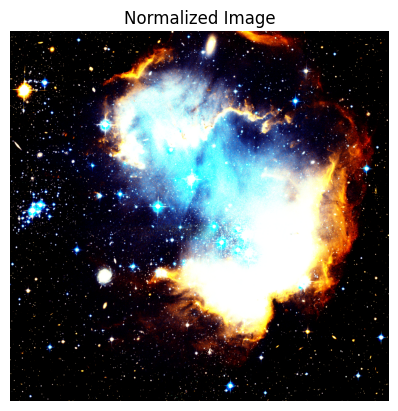

In [86]:
# Step 2 #
blue_mean = np.mean(b)
green_mean = np.mean(g)
red_mean = np.mean(r)
print('B_Mean:',blue_mean,'G_Mean:',green_mean,'R_Mean:',red_mean)

blue_sd = np.std(b)
green_sd = np.std(g)
red_sd = np.std(r)
print('B_StdDev:',blue_sd,'G_StdDev:',green_sd,'R_StdDev:',red_sd)

blue_adj = (b - blue_mean)/blue_sd
green_adj = (g - green_mean)/green_sd
red_adj = (r - red_mean)/red_sd

recon_img = np.stack([blue_adj, green_adj, red_adj], axis=2)
plt.imshow(recon_img)
plt.title('Normalized Image')
plt.axis('off')
plt.show()

In [87]:
# Step 3 #
dim = list(recon_img.shape)
height = dim[0]
width = dim[1]
depth = dim[2]
print('Height:',height,'Width:',width,'Channels:',depth)
print('Data Type:',recon_img.dtype)
pix = height*width*depth
print('Total Pixels:',pix)

Height: 3659 Width: 3749 Channels: 3
Data Type: float64
Total Pixels: 41152773


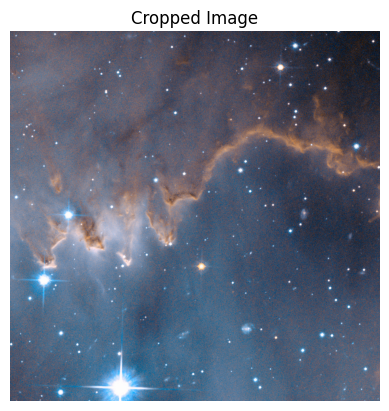

In [88]:
# Step 4 #
x, y = 1500, 500
crop_width, crop_height = 1000, 1000
cropped_img = img_clr[y:y+crop_height, x:x+crop_width]
plt.imshow(cropped_img)
plt.title('Cropped Image')
plt.axis('off')
plt.show()

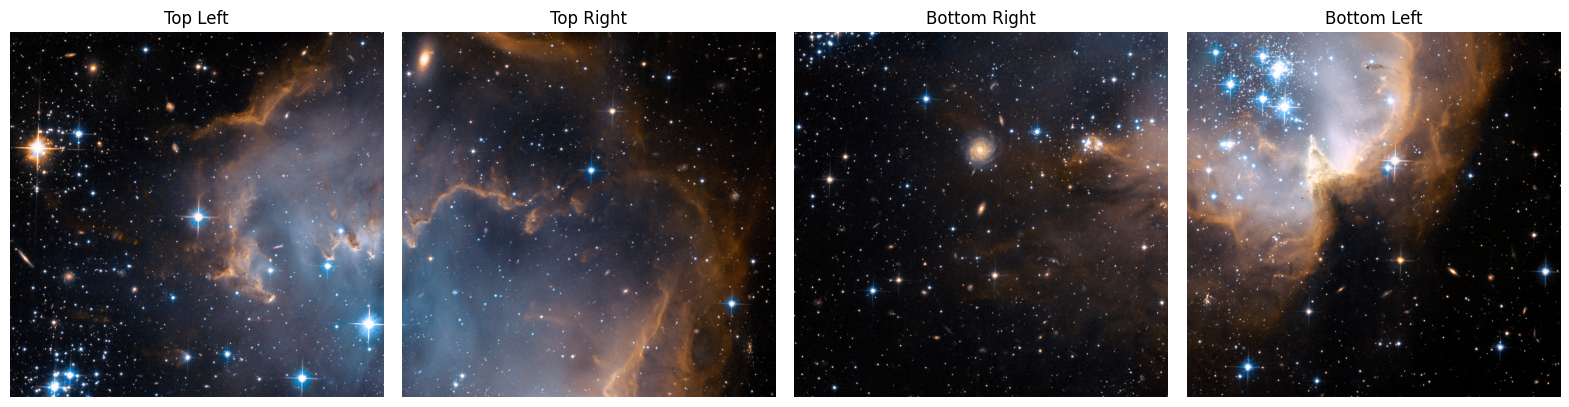

In [89]:
# Step 5 #
half_width = width//2
half_height = height//2
top_left = img_clr[:half_height,:half_width]
bottom_right = img_clr[half_height:,:half_width]
top_right = img_clr[:half_height,half_width:]
bottom_left = img_clr[half_height:,half_width:]
images = [top_left, top_right, bottom_right, bottom_left]
titles = ['Top Left', 'Top Right', 'Bottom Right', 'Bottom Left']
fig, axes = plt.subplots(1,4,figsize=(20,5),gridspec_kw={'wspace':0.05, 'hspace':0})
for ax, image, title in zip(axes,images,titles):
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title)
plt.show()

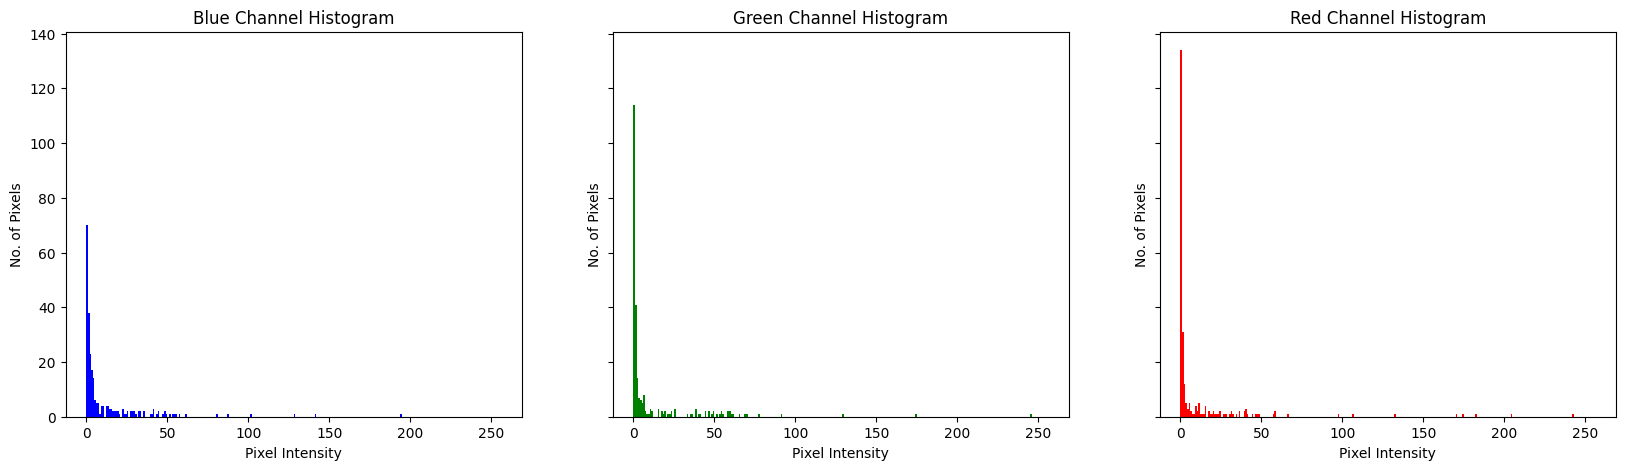

In [90]:
# Step 6 #
hist_1 = cv2.calcHist(b,[0],None,[256],[0,256])
hist_2 = cv2.calcHist(g,[0],None,[256],[0,256])
hist_3 = cv2.calcHist(r,[0],None,[256],[0,256])

fig, axes = plt.subplots(1,3,figsize=(20,5),gridspec_kw={'wspace':0.2, 'hspace':0}, sharey=True)

axes[0].hist(hist_1, bins=256, range = (0,256), color='blue', edgecolor='none')
axes[0].set_title('Blue Channel Histogram')
axes[0].set_ylabel('No. of Pixels')
axes[0].set_xlabel('Pixel Intensity')

axes[1].hist(hist_2, bins=256, range = (0,256), color='green', edgecolor='none')
axes[1].set_title('Green Channel Histogram')
axes[1].set_ylabel('No. of Pixels')
axes[1].set_xlabel('Pixel Intensity')

axes[2].hist(hist_3, bins=256, range = (0,256), color='red', edgecolor='none')
axes[2].set_title('Red Channel Histogram')
axes[2].set_ylabel('No. of Pixels')
axes[2].set_xlabel('Pixel Intensity')

plt.show()

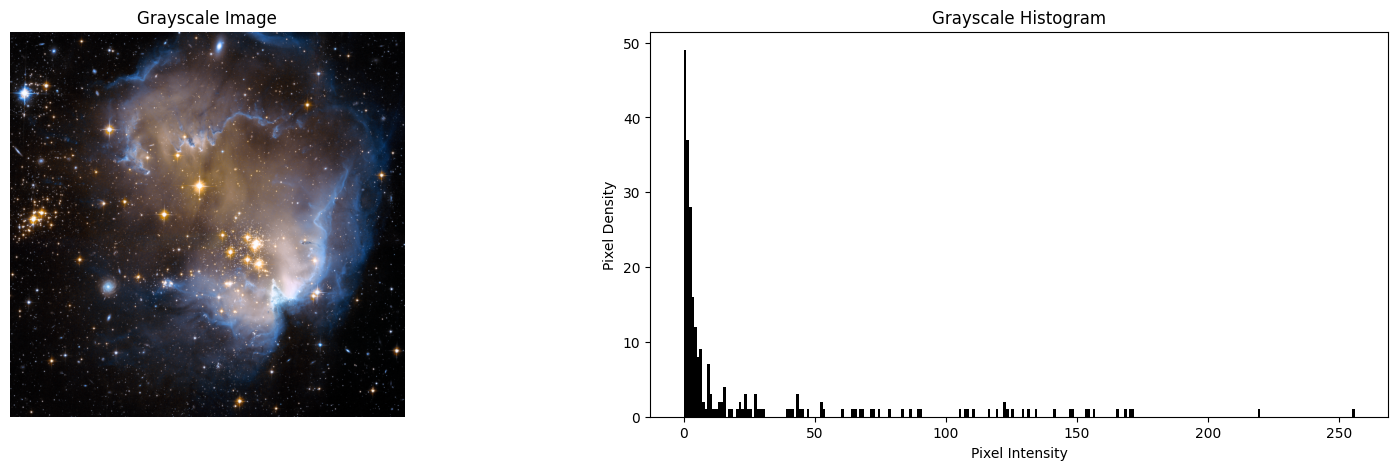

In [91]:
# Step 7 #
img_gys = cv2.imread(img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist(img_gys,[0],None,[256],[0,256])

fig, axes = plt.subplots(1,2,figsize=(20,5),gridspec_kw={'wspace':0.1, 'hspace':0})
axes[0].imshow(img_gys, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Grayscale Image')

axes[1].hist(hist, bins=256, range=(0,256), color='black', edgecolor='none')
axes[1].set_title('Grayscale Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Pixel Density')

plt.show()

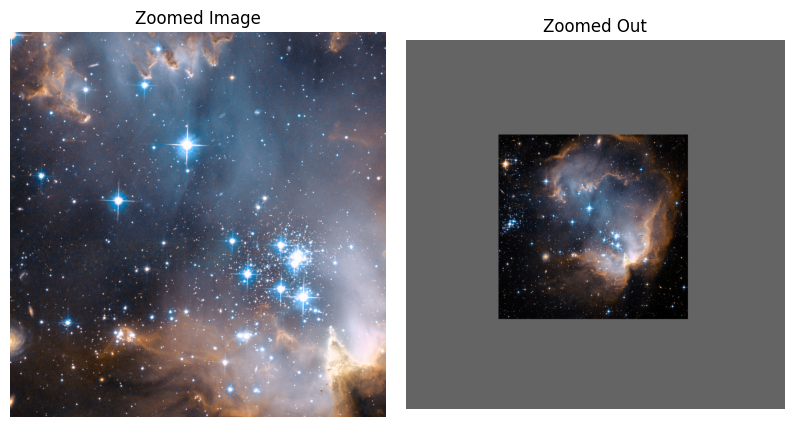

Zoomed In Image Shape: (1874, 1829, 3)
Zoomed Out Image Shape (3659, 3749, 3)


In [92]:
# Step 8 #
quar_height = height//4
quar_width = width//4
zoom_fac = 2
zoom_height, zoom_width = int(width/zoom_fac), int(height/zoom_fac)
start_x, start_y = quar_width, quar_height
img_zoom = img_clr[start_y:start_y+zoom_height, start_x:start_x+zoom_width]
zoomed_img = cv2.resize(img_zoom, (zoom_width, zoom_height), interpolation=cv2.INTER_CUBIC)

center = (height//2, width//2)
matrix = cv2.getRotationMatrix2D(center, 0, 0.5)
zoomed_out = cv2.warpAffine(img_clr, matrix, (width, height), borderMode=cv2.BORDER_CONSTANT, borderValue=[100,100,100])


fig, axes = plt.subplots(1,2,figsize=(10,5),gridspec_kw={'wspace':0.05, 'hspace':0})
axes[0].imshow(zoomed_img)
axes[0].axis('off')
axes[0].set_title('Zoomed Image')
axes[1].imshow(zoomed_out)
axes[1].axis('off')
axes[1].set_title('Zoomed Out')
plt.show()
print('Zoomed In Image Shape:',zoomed_img.shape)
print('Zoomed Out Image Shape',zoomed_out.shape)

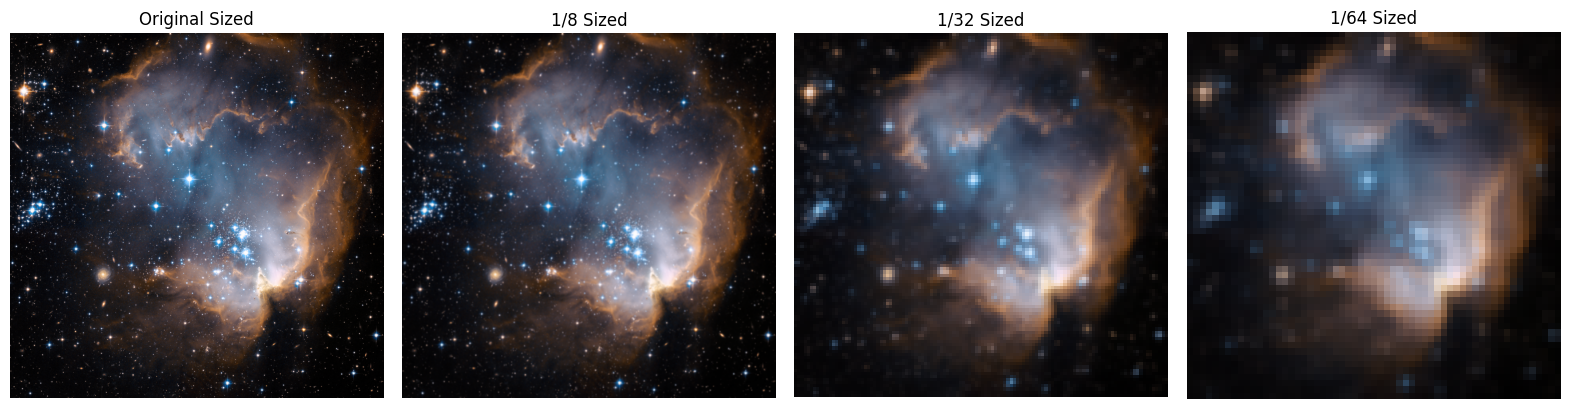

In [93]:
# Step 9 #
lower_1 = cv2.pyrDown(cv2.pyrDown(cv2.pyrDown(img_clr)))
lower_2 = (cv2.pyrDown(cv2.pyrDown(lower_1)))
lower_3 = cv2.pyrDown(lower_2)
images = [img_clr, lower_1, lower_2, lower_3]
titles = ['Original Sized','1/8 Sized', '1/32 Sized', '1/64 Sized']
fig, axes = plt.subplots(1,4,figsize=(20,5),gridspec_kw={'wspace':0.05, 'hspace':0})
for ax, img, title in zip(axes,images,titles):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title)
plt.show()